# Plasmaätzexperiment

Eine Prozessingenieurin untersucht den Zusammenhang zwischen der HF-Leistung (*RF Power*) und der Ätzrate (*Etch Rate*) eines Plasmaätzsystems für Einzelwafer.

Ziel des Experiments ist es festzustellen, ob unterschiedliche Leistungsstufen zu unterschiedlichen mittleren Ätzraten führen.

## Versuchsaufbau

- Faktor: HF-Leistung (*RF Power*)
- Antwortvariable: Ätzrate (*Etch Rate*)
- Vier Faktorstufen:
  - 160 W
  - 180 W
  - 200 W
  - 220 W
- Fünf Wafer pro Leistungsstufe (Wiederholungen)
- Zufällige Versuchsdurchführung (*Completely Randomized Design*)

## Datengrundlage

![title](img/table3-1.png)

## Ziele der Analyse

- Grafische Untersuchung der Daten
- Einfaktorielle Varianzanalyse (One-Factor ANOVA)
- Vergleich der Mittelwerte (Multiple Comparisons)
- Überprüfung der Modellannahmen

# Dateneingabe

Zunächst werden die Versuchsdaten in einen DataFrame eingelesen.

Jede Beobachtung besteht aus einer Kombination von HF-Leistung und gemessener Ätzrate.

In [1]:
import pandas as pd

df = pd.DataFrame({
    "Power": [
        160,160,160,160,160,
        180,180,180,180,180,
        200,200,200,200,200,
        220,220,220,220,220
    ],
    "EtchRate": [
        575,542,530,539,570,
        565,593,590,579,610,
        600,651,610,637,629,
        725,700,715,685,710
    ]
})

df


,Power,EtchRate
0,160,575
1,160,542
2,160,530
3,160,539
4,160,570
5,180,565
6,180,593
7,180,590
8,180,579
9,180,610


# Grafische Analyse

Vor jeder statistischen Analyse sollten die Daten visualisiert werden.

Die folgenden Diagramme ermöglichen einen ersten Vergleich der Ätzraten für die vier Leistungsstufen.

Besonders interessant sind:

- Unterschiede der Gruppenmittelwerte
- Streuung innerhalb der Gruppen
- mögliche Ausreißer

## Boxplot

Der Boxplot zeigt die Verteilung der Ätzraten für jede Leistungsstufe.

Er ermöglicht eine erste Einschätzung, ob sich die mittleren Ätzraten unterscheiden und ob die Streuungen der Gruppen vergleichbar sind.

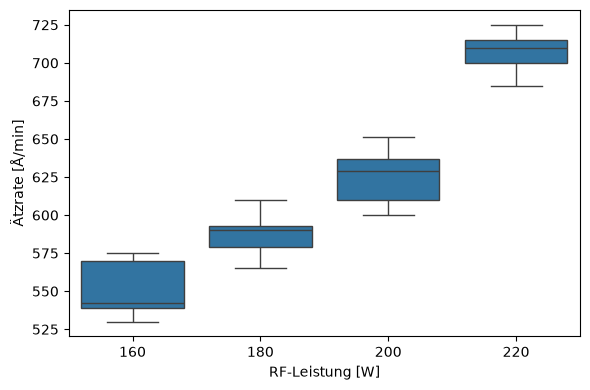

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Power",
    y="EtchRate"
)

plt.xlabel("RF-Leistung [W]")
plt.ylabel("Ätzrate [Å/min]")

plt.tight_layout()

plt.show()

## Streudiagramm

Zusätzlich zum Boxplot betrachten wir die einzelnen Beobachtungen.

Dadurch wird sichtbar, wie stark die Messwerte innerhalb einer Leistungsstufe streuen.

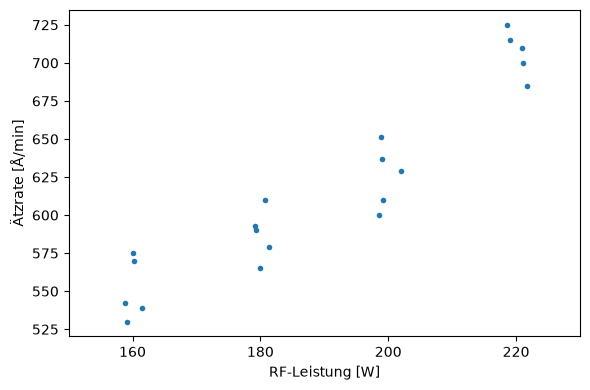

In [3]:
plt.figure(figsize=(6,4))

sns.stripplot(
    data=df,
    x="Power",
    y="EtchRate",
    size=4
)

plt.xlabel("RF-Leistung [W]")
plt.ylabel("Ätzrate [Å/min]")

plt.tight_layout()

plt.show()

In [4]:
df.groupby("Power")["EtchRate"].agg(
    ["count","mean","std"]
)

,count,mean,std
Power,,,
160,5,551.2,20.017492
180,5,587.4,16.742162
200,5,625.4,20.525594
220,5,707.0,15.247951


# Einfaktorielle Varianzanalyse (ANOVA)

Die ANOVA untersucht, ob die mittleren Ätzraten für alle Leistungsstufen gleich sind.

## Hypothesen

$H_0:\mu_{160}=\mu_{180}=\mu_{200}=\mu_{220}$

$H_1:\text{Mindestens ein Mittelwert unterscheidet sich.}$

Die ANOVA vergleicht die Variabilität zwischen den Gruppen mit der Variabilität innerhalb der Gruppen.

## ANOVA-Tabelle

Die ANOVA-Tabelle enthält:

- Quadratsummen (SS)
- Freiheitsgrade (df)
- Mittlere Quadratsummen (MS)
- F-Teststatistik
- p-Wert

Große Werte der F-Teststatistik sprechen für Unterschiede zwischen den Mittelwerten.

In [9]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

model = ols(
    "EtchRate ~ C(Power)",
    data=df
).fit()

anova_table = anova_lm(
    model,
    typ=2
)

anova_table

,sum_sq,df,F,PR(>F)
C(Power),66870.55,3.0,66.797073,2.882866e-09
Residual,5339.20,16.0,NaN,NaN


In [10]:
import numpy as np
anova_table2 = anova_lm(model, typ=2)

anova_table2["MS"] = (
    anova_table2["sum_sq"]
    / anova_table2["df"]
)

ss_total = (
    (df["EtchRate"] - df["EtchRate"].mean())**2
).sum()

df_total = len(df) - 1

total_row = pd.DataFrame(
    {
        "sum_sq": [ss_total],
        "df": [df_total],
        "F": [np.nan],
        "PR(>F)": [np.nan],
        "MS": [np.nan]
    },
    index=["Total"]
)

anova_table2 = pd.concat(
    [anova_table2, total_row]
)



anova_table2 = (
    anova_table2[
        ["df", "sum_sq", "MS", "F", "PR(>F)"]
    ]
    .rename(
        columns={
            "df": "DF",
            "sum_sq": "SS",
            "PR(>F)": "p-value"
        }
    )
)


anova_table2.round(2)

,DF,SS,MS,F,p-value
C(Power),3.0,66870.55,22290.18,66.8,0.0
Residual,16.0,5339.20,333.70,NaN,NaN
Total,19.0,72209.75,NaN,NaN,NaN


# Mittelwertvergleich

Die ANOVA zeigt nur, dass mindestens ein Mittelwert unterschiedlich ist.

Sie beantwortet jedoch nicht die Frage, welche Leistungsstufen sich voneinander unterscheiden.

Daher führen wir anschließend einen Vergleich der Mittelwerte durch.

## Fisher Least Significant Difference (LSD)

Die Fisher-LSD-Methode basiert auf paarweisen Mittelwertvergleichen.

Zunächst wird ein kritischer Unterschied (Least Significant Difference) berechnet:

$
LSD
=
t_{\alpha/2,N-a}
\sqrt{\frac{2MS_E}{n}}
$

Zwei Mittelwerte unterscheiden sich signifikant, wenn ihre Differenz größer als der LSD-Wert ist.

In [11]:
from scipy.stats import t

alpha = 0.05

MSE = anova_table.loc["Residual","sum_sq"] / anova_table.loc["Residual","df"]

n = 5

df_error = int(anova_table.loc["Residual","df"])

tcrit = t.ppf(
    1 - alpha/2,
    df_error
)

LSD = tcrit * np.sqrt(
    2*MSE/n
)

print("Fisher LSD")
print("-"*50)

print(f"MSE = {MSE:.2f}")
print(f"df_error = {df_error}")
print(f"t critical = {tcrit:.3f}")

print(f"\nLSD = {LSD:.3f}")

Fisher LSD
--------------------------------------------------
MSE = 333.70
df_error = 16
t critical = 2.120

LSD = 24.492


In [12]:
from itertools import combinations

means = (
    df.groupby("Power")["EtchRate"]
      .mean()
)

print(f"\nLSD = {LSD:.3f}\n")

for a, b in combinations(means.index, 2):

    diff = abs(
        means[a] - means[b]
    )

    print(
        f"{a} W vs {b} W: "
        f"|Δ| = {diff:.1f} "
        f"{'>' if diff > LSD else '<='} "
        f"{LSD:.1f}"
    )


LSD = 24.492

160 W vs 180 W: |Δ| = 36.2 > 24.5
160 W vs 200 W: |Δ| = 74.2 > 24.5
160 W vs 220 W: |Δ| = 155.8 > 24.5
180 W vs 200 W: |Δ| = 38.0 > 24.5
180 W vs 220 W: |Δ| = 119.6 > 24.5
200 W vs 220 W: |Δ| = 81.6 > 24.5


## Tukey HSD

In der Praxis wird häufig die Tukey-HSD-Methode verwendet.

Im Gegensatz zu Fisher LSD berücksichtigt Tukey die Tatsache, dass mehrere Vergleiche gleichzeitig durchgeführt werden.

Dadurch wird die Gesamtfehlerwahrscheinlichkeit besser kontrolliert.

In [13]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    df["EtchRate"],
    df["Power"]
)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
   160    180     36.2 0.0294   3.1456  69.2544   True
   160    200     74.2    0.0  41.1456 107.2544   True
   160    220    155.8    0.0 122.7456 188.8544   True
   180    200     38.0 0.0216   4.9456  71.0544   True
   180    220    119.6    0.0  86.5456 152.6544   True
   200    220     81.6    0.0  48.5456 114.6544   True
------------------------------------------------------


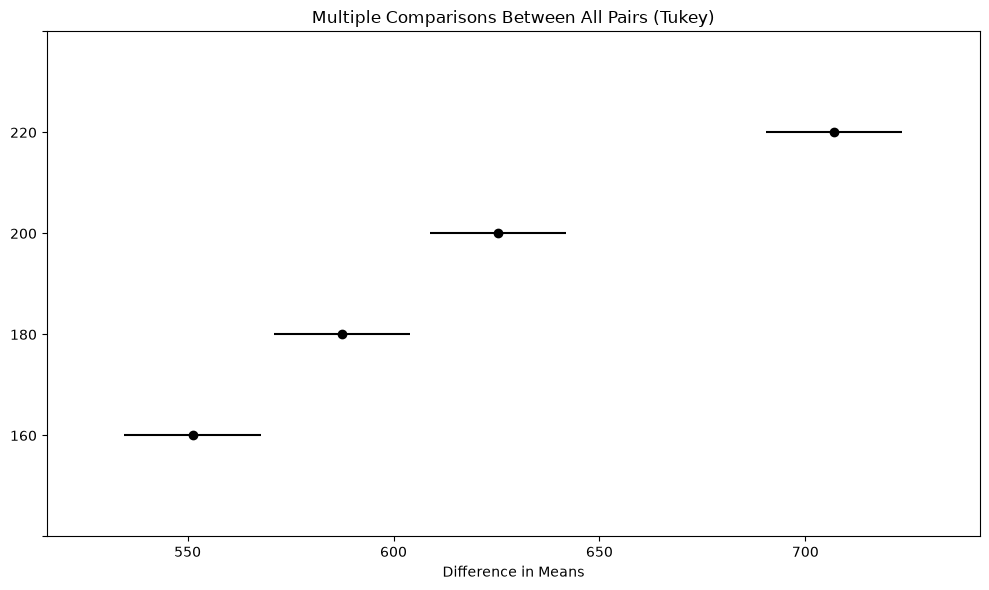

In [14]:
tukey.plot_simultaneous()

plt.xlabel("Difference in Means")

plt.tight_layout()

plt.show()

# Überprüfung der Modellannahmen

Die ANOVA beruht auf mehreren Annahmen:

- Normalverteilung der Fehler
- Konstante Varianz
- Unabhängigkeit der Beobachtungen

Diese Annahmen werden anhand der Residuen überprüft.

## Normalverteilung der Residuen

Ein Normal Probability Plot vergleicht die beobachteten Residuen mit den Quantilen einer Normalverteilung.

Liegen die Punkte näherungsweise auf einer Geraden, erscheint die Normalitätsannahme plausibel.

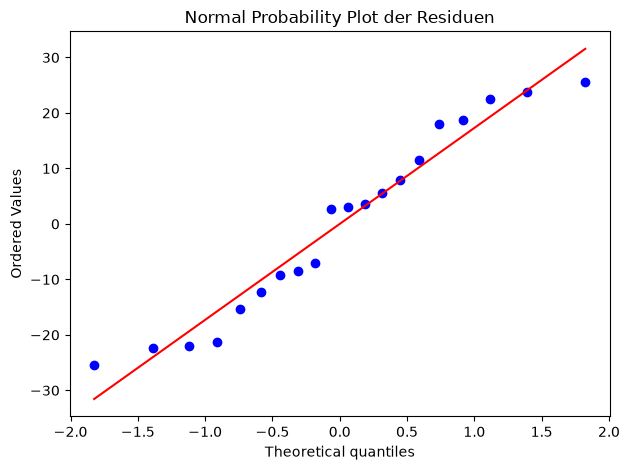

In [15]:
from scipy import stats

stats.probplot(
    model.resid,
    dist="norm",
    plot=plt
)

plt.title(
    "Normal Probability Plot der Residuen"
)

plt.tight_layout()


plt.show()

## Residuen gegen vorhergesagte Werte

Dieser Plot dient zur Überprüfung der Annahme gleicher Varianzen.

Gesucht wird eine zufällige Streuung der Residuen ohne erkennbare Struktur.

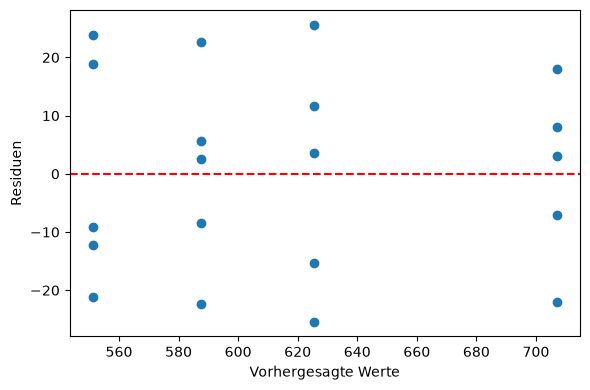

In [16]:
plt.figure(figsize=(6,4))

plt.scatter(
    model.fittedvalues,
    model.resid
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Vorhergesagte Werte")
plt.ylabel("Residuen")

plt.tight_layout()


plt.show()

# Regressionsmodell

Die HF-Leistung ist eine kontinuierliche Einflussgröße.

Daher kann zusätzlich ein Regressionsmodell angepasst werden.

Während die ANOVA die Gleichheit der Mittelwerte untersucht, beschreibt die Regression den funktionalen Zusammenhang zwischen Leistung und Ätzrate.

In [17]:
linear_model = ols(
    "EtchRate ~ Power",
    data=df
).fit()

print(linear_model.params)

Intercept    137.620
Power          2.527
dtype: float64


In [18]:
df["Power2"] = df["Power"]**2

quad_model = ols(
    "EtchRate ~ Power + Power2",
    data=df
).fit()

print(quad_model.params)

Intercept    1147.770000
Power          -8.255500
Power2          0.028375
dtype: float64


## Quadratische Regression

Die folgende Grafik zeigt die mittleren Ätzraten sowie eine quadratische Regressionskurve.

Anhand dieser Kurve kann später untersucht werden, welche Leistungsstufe zu einer gewünschten Zielätzrate führt.

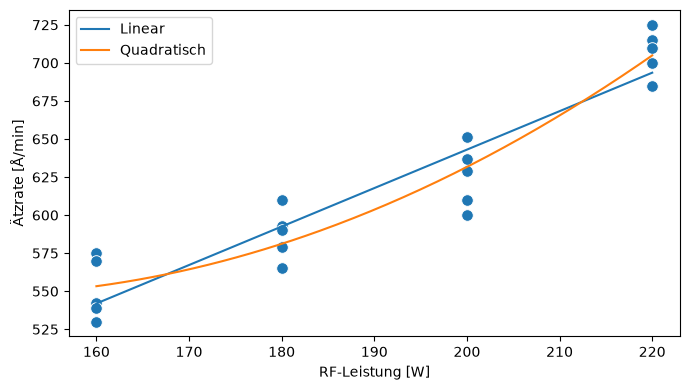

In [20]:
x = np.linspace(160,220,200)

y_linear = (
    linear_model.params["Intercept"]
    + linear_model.params["Power"]*x
)

y_quad = (
    quad_model.params["Intercept"]
    + quad_model.params["Power"]*x
    + quad_model.params["Power2"]*x**2
)

plt.figure(figsize=(7,4))

sns.scatterplot(
    data=df,
    x="Power",
    y="EtchRate",
    s=70
)

plt.plot(
    x,
    y_linear,
    label="Linear"
)

plt.plot(
    x,
    y_quad,
    label="Quadratisch"
)

plt.xlabel("RF-Leistung [W]")
plt.ylabel("Ätzrate [Å/min]")

plt.legend()

plt.tight_layout()


plt.show()

# Zusammenfassung

Die ANOVA zeigt einen signifikanten Einfluss der HF-Leistung auf die Ätzrate.

Die Mittelwertvergleiche zeigen, welche Leistungsstufen sich voneinander unterscheiden.

Die Residuenanalyse liefert keine Hinweise auf schwerwiegende Verletzungen der Modellannahmen.

Damit erscheint die ANOVA für dieses Experiment angemessen.